# ALMA moment-0 contours on rotated JWST RGB images

The columns show SiO (2-1), CH$_3$OH $2(0,2)-1(0,1)^{++}$, and CS (2-1). MIRI is shown above NIRCam. White contours are 2, 5, 10, and 20 times the per-map MAD, the dashed line is the full ALMA image boundary, and the restoring beam is shown at lower right.


In [1]:
from pathlib import Path

import astropy.units as u
import matplotlib
import numpy as np
from astropy.io import fits
from astropy.stats import mad_std
from astropy.wcs import WCS
from astropy.wcs.utils import proj_plane_pixel_scales
from matplotlib.image import imread
from matplotlib.patches import Ellipse
from PIL import Image
from scipy.ndimage import binary_propagation, label, map_coordinates

import matplotlib.pyplot as plt


Image.MAX_IMAGE_PIXELS = None

REPO_DIR = Path('/Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows')
ALMA_DIR = Path(
    "/Users/abarnes/Library/CloudStorage/Dropbox/Data/Galactic/JWST/cloud_h/alma"
)
JWST_DIR = Path(
    "/Users/abarnes/Library/CloudStorage/Dropbox/Data/Galactic/JWST/cloud_h/"
    "jwst/fits/nanfilled/reprojected"
)
PLOT_DIR = REPO_DIR / "plots"

MIRI_JPEG = JWST_DIR / "miri_photoshop.jpeg"
MIRI_WCS_FITS = (
    JWST_DIR / "jw07230-o002_t003_miri_f770w_i2d_nanfilled_reprojected.fits"
)
NIRCAM_JPEG = JWST_DIR / "nircam_photoshop.jpeg"
NIRCAM_WCS_FITS = (
    JWST_DIR
    / "jw07230-o004_t003_nircam_clear-f356w_i2d_nanfilled_reprojected.fits"
)

MOMENT0_MAPS = [
    (
        r"SiO (2$-$1)",
        ALMA_DIR
        / "member.uid___A001_X879_X395.CloudH_sci.spw27.cube.I.pbcor_"
        "SiO_2-1_moment0.fits",
    ),
    (
        r"CH$_3$OH $2(0,2)-1(0,1)^{++}$",
        ALMA_DIR
        / "member.uid___A001_X879_X395.CloudH_sci.spw33.cube.I.pbcor_"
        "CH3OH_2(0,2)-1(0,1)++_moment0.fits",
    ),
    (
        r"CS (2$-$1)",
        ALMA_DIR
        / "member.uid___A001_X879_X395.CloudH_sci.spw37.cube.I.pbcor_"
        "CS_2-1_moment0.fits",
    ),
]

DISPLAY_PA_DEG = 354.80557109226515 - 360
FOOTPRINT_PADDING_PIXELS = 12
MIRI_WHITE_THRESHOLD = 245
CONTOUR_MULTIPLES = np.array([2, 5, 10, 20], dtype=float)
MIN_CONTOUR_PIXELS = 20

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"


In [2]:
def read_rgb_and_wcs(jpeg_path, fits_path):
    """Read one RGB JPEG and the celestial WCS of its matching FITS image."""
    rgb = np.flipud(imread(jpeg_path)[..., :3]).copy()
    with fits.open(fits_path, memmap=True) as hdul:
        image_shape = hdul[1].data.shape
        image_wcs = WCS(hdul[1].header).celestial
    if rgb.shape[:2] != image_shape:
        raise ValueError(
            f"{jpeg_path.name} shape {rgb.shape[:2]} does not match "
            f"{fits_path.name} shape {image_shape}."
        )
    return rgb, image_wcs


def read_moment0(moment0_path):
    """Read a two-dimensional moment-0 map, celestial WCS, and restoring beam."""
    with fits.open(moment0_path, memmap=True) as hdul:
        data = np.squeeze(hdul[0].data).astype(float)
        header = hdul[0].header.copy()
    if data.ndim != 2:
        raise ValueError(f"{moment0_path.name} does not reduce to 2-D: {data.shape}.")
    if not np.isfinite(data).any():
        raise ValueError(f"{moment0_path.name} has no finite values.")
    beam = {
        "major_arcsec": header["BMAJ"] * 3600,
        "minor_arcsec": header["BMIN"] * 3600,
        "pa_deg": header["BPA"],
    }
    return data, WCS(header).celestial, beam


def make_rotated_wcs(alma_wcs, alma_shape, pixel_scale_arcsec):
    """Build a rotated output grid enclosing the complete ALMA image."""
    height, width = alma_shape
    edge_x = np.concatenate(
        [np.arange(width), np.arange(width), np.zeros(height), np.full(height, width - 1)]
    )
    edge_y = np.concatenate(
        [np.zeros(width), np.full(width, height - 1), np.arange(height), np.arange(height)]
    )
    edge_world = alma_wcs.pixel_to_world(edge_x, edge_y)
    center = alma_wcs.pixel_to_world((width - 1) / 2, (height - 1) / 2)

    rotation = np.deg2rad(DISPLAY_PA_DEG + 90)
    display_wcs = WCS(naxis=2)
    display_wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    display_wcs.wcs.cunit = ["deg", "deg"]
    display_wcs.wcs.crval = [center.ra.deg, center.dec.deg]
    display_wcs.wcs.crpix = [1, 1]
    display_wcs.wcs.cdelt = [pixel_scale_arcsec / 3600, pixel_scale_arcsec / 3600]
    display_wcs.wcs.pc = np.array([[-1, 0], [0, 1]]) @ np.array(
        [
            [np.cos(rotation), -np.sin(rotation)],
            [np.sin(rotation), np.cos(rotation)],
        ]
    )
    display_wcs.wcs.set()

    edge_display_x, edge_display_y = display_wcs.world_to_pixel(edge_world)
    xmin, xmax = edge_display_x.min(), edge_display_x.max()
    ymin, ymax = edge_display_y.min(), edge_display_y.max()
    display_width = int(np.ceil(xmax - xmin + 1 + 2 * FOOTPRINT_PADDING_PIXELS))
    display_height = int(np.ceil(ymax - ymin + 1 + 2 * FOOTPRINT_PADDING_PIXELS))
    display_wcs.wcs.crpix = [
        1 - xmin + FOOTPRINT_PADDING_PIXELS,
        1 - ymin + FOOTPRINT_PADDING_PIXELS,
    ]
    display_wcs.wcs.set()
    return display_wcs, display_width, display_height


def sample_rgb(rgb, input_wcs, ra, dec):
    x, y = input_wcs.world_to_pixel_values(ra, dec)
    sampled = np.empty(ra.shape + (3,), dtype=rgb.dtype)
    for channel in range(3):
        sampled[..., channel] = map_coordinates(
            rgb[..., channel], [y, x], order=1, mode="constant", cval=0
        )
    return sampled


def sample_map(data, input_wcs, ra, dec):
    x, y = input_wcs.world_to_pixel_values(ra, dec)
    sampled_data = map_coordinates(
        data, [y, x], order=1, mode="constant", cval=np.nan
    )
    footprint = map_coordinates(
        np.ones(data.shape, dtype=float),
        [y, x],
        order=0,
        mode="constant",
        cval=0,
    )
    return sampled_data, footprint


def filter_small_contour_regions(data, footprint, levels):
    """Remove isolated above-level contour regions smaller than the chosen limit."""
    valid = np.isfinite(data) & (footprint > 0.5)
    filtered_masks = []
    for level_value in levels:
        components, _ = label(
            valid & (data >= level_value), structure=np.ones((3, 3), dtype=int)
        )
        pixel_counts = np.bincount(components.ravel())
        keep_component = pixel_counts >= MIN_CONTOUR_PIXELS
        keep_component[0] = False
        filtered_masks.append((level_value, keep_component[components]))
    return filtered_masks


def celestial_grids_match(first_wcs, second_wcs, image_shape):
    """Check the sky coordinates at the center and four image corners."""
    height, width = image_shape
    x = np.array([0, width - 1, width - 1, 0, (width - 1) / 2])
    y = np.array([0, 0, height - 1, height - 1, (height - 1) / 2])
    first_ra, first_dec = first_wcs.pixel_to_world_values(x, y)
    second_ra, second_dec = second_wcs.pixel_to_world_values(x, y)
    return np.allclose(first_ra, second_ra, atol=1e-10, rtol=0) and np.allclose(
        first_dec, second_dec, atol=1e-10, rtol=0
    )


In [15]:
def main():
    missing_paths = [
        file_path
        for file_path in [MIRI_JPEG, MIRI_WCS_FITS, NIRCAM_JPEG, NIRCAM_WCS_FITS]
        + [moment0_path for _, moment0_path in MOMENT0_MAPS]
        if not file_path.is_file()
    ]
    if missing_paths:
        missing_names = "\n".join(f"  {file_path}" for file_path in missing_paths)
        raise FileNotFoundError(f"Missing plotting inputs:\n{missing_names}")

    miri_rgb, miri_wcs = read_rgb_and_wcs(MIRI_JPEG, MIRI_WCS_FITS)
    nircam_rgb, nircam_wcs = read_rgb_and_wcs(NIRCAM_JPEG, NIRCAM_WCS_FITS)

    miri_white = np.all(miri_rgb >= MIRI_WHITE_THRESHOLD, axis=2)
    miri_edge = np.zeros(miri_white.shape, dtype=bool)
    miri_edge[[0, -1], :] = True
    miri_edge[:, [0, -1]] = True
    miri_rgb[binary_propagation(miri_edge & miri_white, mask=miri_white)] = 0

    miri_pixel_scale = (
        np.mean(proj_plane_pixel_scales(miri_wcs)) * u.deg
    ).to_value(u.arcsec)
    prepared_maps = []
    for line_label, moment0_path in MOMENT0_MAPS:
        moment0, moment0_wcs, beam = read_moment0(moment0_path)
        prepared_maps.append((line_label, moment0_path, moment0, moment0_wcs, beam))

    reference_shape = prepared_maps[0][2].shape
    reference_wcs = prepared_maps[0][3]
    for _, moment0_path, moment0, moment0_wcs, _ in prepared_maps[1:]:
        if moment0.shape != reference_shape or not celestial_grids_match(
            reference_wcs, moment0_wcs, reference_shape
        ):
            raise ValueError(
                f"{moment0_path.name} does not share the reference spatial grid."
            )

    display_wcs, display_width, display_height = make_rotated_wcs(
        reference_wcs, reference_shape, miri_pixel_scale
    )
    display_y, display_x = np.mgrid[0:display_height, 0:display_width]
    ra, dec = display_wcs.pixel_to_world_values(display_x, display_y)
    display_miri = sample_rgb(miri_rgb, miri_wcs, ra, dec)
    display_nircam = sample_rgb(nircam_rgb, nircam_wcs, ra, dec)

    fig = plt.figure(figsize=(11, 6.5))
    for column, (line_label, moment0_path, moment0, moment0_wcs, beam) in enumerate(
        prepared_maps, start=1
    ):
        display_moment0, display_footprint = sample_map(
            moment0, moment0_wcs, ra, dec
        )
        sigma = mad_std(moment0[np.isfinite(moment0)], ignore_nan=True)
        levels = CONTOUR_MULTIPLES * sigma
        filtered_contours = filter_small_contour_regions(
            display_moment0, display_footprint, levels
        )
        print(
            f"{moment0_path.name}: sigma={sigma:.4g} K km/s, "
            f"levels={np.array2string(levels, precision=4)}"
        )

        for row, (image, instrument) in enumerate(
            ((display_miri, "MIRI"), (display_nircam, "NIRCam"))
        ):
            ax = fig.add_subplot(2, 3, row * 3 + column, projection=display_wcs)
            ax.set_facecolor("black")
            ax.imshow(image, origin="lower")
            for _, filtered_mask in filtered_contours:
                if filtered_mask.any():
                    ax.contour(
                        filtered_mask.astype(float),
                        levels=[0.5],
                        colors="white",
                        linewidths=1.25,
                        alpha=0.65,
                    )
            ax.contour(
                display_footprint,
                levels=[0.5],
                colors="white",
                linestyles="--",
                linewidths=1.0,
            )
            ax.add_patch(
                Ellipse(
                    (0.91 * display_width, 0.08 * display_height),
                    width=beam["major_arcsec"] / miri_pixel_scale,
                    height=beam["minor_arcsec"] / miri_pixel_scale,
                    angle=beam["pa_deg"] - DISPLAY_PA_DEG,
                    facecolor="none",
                    edgecolor="white",
                    linewidth=1.5,
                    alpha=0.9,
                )
            )
            ax.coords.grid(color="white", alpha=0.35, linestyle=":")
            ax.coords[0].set_ticklabel_visible(False)
            ax.coords[1].set_ticklabel_visible(False)
            ax.coords[0].set_axislabel("")
            ax.coords[1].set_axislabel("")
            ax.text(
                0.02,
                0.96,
                line_label,
                transform=ax.transAxes,
                ha="left",
                va="top",
                fontsize=10,
                fontweight="bold",
                color="white",
                bbox=dict(
                    boxstyle="round,pad=0.28",
                    facecolor="black",
                    edgecolor="white",
                    linewidth=0.8,
                    alpha=0.72,
                ),
            )
            ax.text(
                0.02,
                0.04,
                instrument,
                transform=ax.transAxes,
                ha="left",
                va="bottom",
                fontsize=10,
                fontweight="bold",
                color="white",
                bbox=dict(
                    boxstyle="round,pad=0.28",
                    facecolor="black",
                    edgecolor="white",
                    linewidth=0.8,
                    alpha=0.72,
                ),
            )

    fig.tight_layout()
    fig.subplots_adjust(wspace=0.02, hspace=-0.05)
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    for extension in ("pdf", "png"):
        output_path = PLOT_DIR / f"alma_moment0_contours_nircam_miri_rotated.{extension}"
        fig.savefig(output_path, dpi=300, bbox_inches="tight")
        print(f"Saved {output_path}")
    plt.show()


Set DATE-AVG to '2026-04-20T19:13:48.581' from MJD-AVG.
Set DATE-END to '2026-04-20T20:21:51.119' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -19.247298 from OBSGEO-[XYZ].
Set OBSGEO-H to 1505726645.939 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2026-05-12T02:20:38.473' from MJD-AVG.
Set DATE-END to '2026-05-12T02:31:06.605' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -29.337902 from OBSGEO-[XYZ].
Set OBSGEO-H to 1674445997.841 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


member.uid___A001_X879_X395.CloudH_sci.spw27.cube.I.pbcor_SiO_2-1_moment0.fits: sigma=0.2789 K km/s, levels=[0.5577 1.3944 2.7887 5.5775]
member.uid___A001_X879_X395.CloudH_sci.spw33.cube.I.pbcor_CH3OH_2(0,2)-1(0,1)++_moment0.fits: sigma=0.4733 K km/s, levels=[0.9466 2.3664 4.7328 9.4656]
member.uid___A001_X879_X395.CloudH_sci.spw37.cube.I.pbcor_CS_2-1_moment0.fits: sigma=0.5409 K km/s, levels=[ 1.0817  2.7043  5.4085 10.817 ]
Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_moment0_contours_nircam_miri_rotated.pdf
Saved /Users/abarnes/Library/CloudStorage/Dropbox/GitHub/cloudh_outflows/plots/alma_moment0_contours_nircam_miri_rotated.png


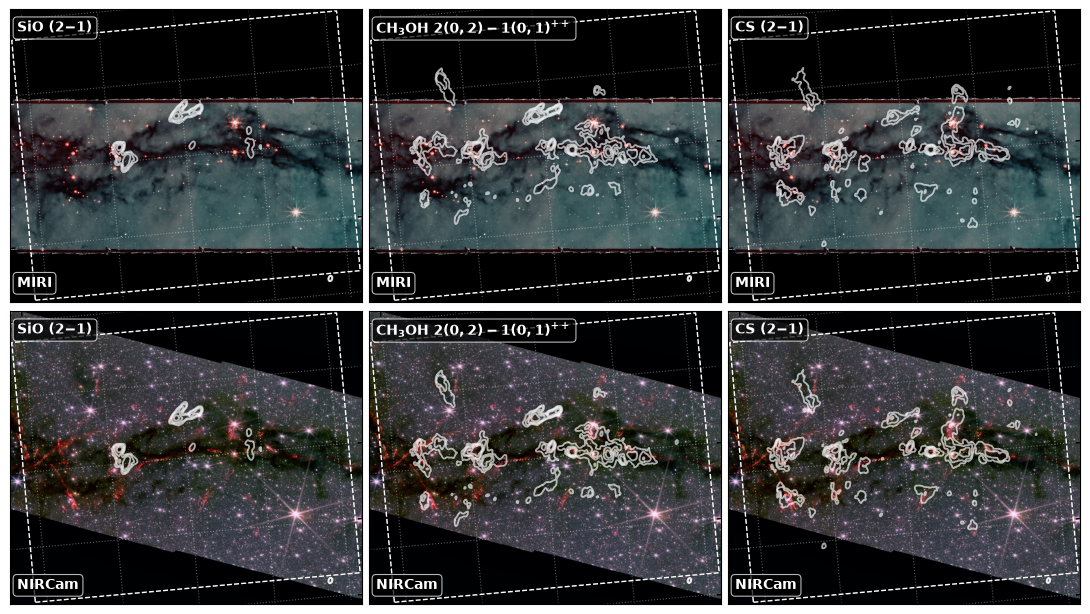

In [16]:
main()
